## Pre-requisites
1. Download the traces recorded from the experiments before running this notebook
2. Command to download the traces. `modal volume get duet-volume ./traces /traces`

In [1]:
# General imports.
import numpy as np
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer




import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)


# Profiling metrics live in duet/profiling/metrics.py (single source of truth).
from duet.profiling import (
    load_traces,
    wall_clock_span,
    bubble_ratio_sweep,
    slowest_ten_percent,
    get_per_prompt_length_and_reward,
    plot_per_prompt_generation_time,
)

/Users/samtheophilus/Documents/projects/fatima/DUET


In [ ]:
# Setting up Constants

In [2]:
MODEL_NAME: str = "Qwen/Qwen2.5-Math-1.5B"
TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME)

In [17]:
# Trace json containing the rollout data from Pytorch Profile
#TRACE_NAME: str = "rank0.1783097036625721759.pt.trace.json.gz"
TRACE_NAME: str = "rank0.1784555454497338364.pt.trace.json.gz"
ROLLOUT_TRACE_PATH: Path = Path(f"../traces/agent_loop_rollout_replica_0/{TRACE_NAME}")
# Experiment data saved during the verl-grpo experiments
DB_PATH = Path("../traces/duet-data/duet.db") 
# Rollout duration for each prompt's rollout during the generation phase.
TIMING_DIR: Path = Path("../traces/gen_times/")
PER_PROMPT_DATA = Path("../traces/rollout_data/2.jsonl")


## Core metrics
The profiling functions (`load_traces`, `wall_clock_span`, `bubble_ratio_sweep`, `slowest_ten_percent`, `get_per_prompt_length_and_reward`, `plot_per_prompt_generation_time`) now live in [`duet/profiling/metrics.py`](../duet/profiling/metrics.py) and are imported in the first cell, so the notebook and any scripts share one implementation.

## Calculate & Display Metrics

In [6]:
# Compute the rollout wall-clock span
rollout_events = load_traces(ROLLOUT_TRACE_PATH)
rollout_wall_clock_span_us = wall_clock_span(rollout_events)
rollout_wall_clock_span_s = rollout_wall_clock_span_us / (1000 * 1000)
print(f"Rollout wall-clock span: {rollout_wall_clock_span_s:.2f}s.")

Rollout wall-clock span: 119.83s.


In [11]:
durations = np.load(TIMING_DIR / "gen_time_call002.npy")

In [12]:
# Compute the bubble ratio for the rollout.
br = bubble_ratio_sweep(durations)
print(f"Bubble ratio: {br:.3f}  ({br*100:.1f}%)")

Bubble ratio: 0.457  (45.7%)


In [13]:
# Slowest 10% by per-request DURATION (lower bound: vLLM continuous batching +
# max_response_length cap smooth the tail; see the resp_len version below).
slowest_ten = slowest_ten_percent(durations)
print(f"Slowest_10% (duration):  {slowest_ten:.1f} %")

Slowest_10% (duration):  17.8 %


In [15]:
## Load rollout jsonl as a dataframe
rollout_df = pd.read_json(PER_PROMPT_DATA, lines=True)
# print(rollout_df.columns.tolist())
# print(len(rollout_df), "rows")
# rollout_df[["gts", "score"]].head(100)

In [19]:
# Fetch the per-prompt length and reward.
result_df = get_per_prompt_length_and_reward(rollout_df, TOKENIZER)
result_df.head(10) 

,gts,output,resp_len,score
0,39,24,2,0
1,16,one year ago\n0\nHelpful past,9,0
2,9,5 DONE,2,0
3,2,Your answer will be calculated automatically.,7,0
4,24,.\n\n\n\nWe can answer any questions you have!,9,0
5,21,48,2,0
6,260,Please create a word phrase to represent the e...,18,0
7,50,_rand_number(),3,0
8,154,A.fraction\n album\naccount\n\n \n\nuttering\n...,14,0
9,35,\n \boxed{135} students in the Chess C...,18,0


In [20]:
# Slowest 10% by RESPONSE LENGTH -- the tail DUET actually targets.
# Length drives rollout compute even when continuous batching hides it in per-request time.
slowest_ten_len = slowest_ten_percent(result_df["resp_len"].values)
print(f"Slowest_10% (resp_len):  {slowest_ten_len:.1f} %")

Slowest_10% (resp_len):  18.4 %


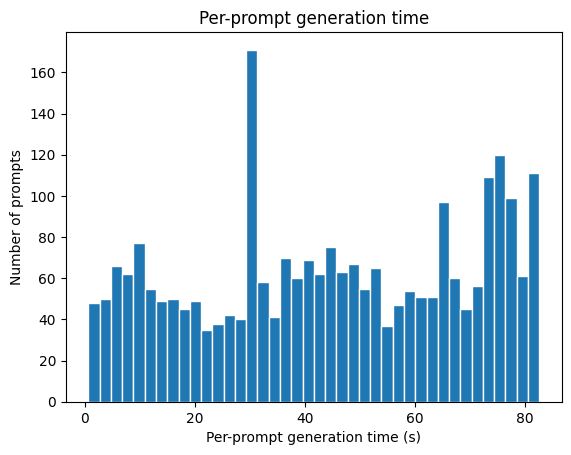

<Axes: title={'center': 'Per-prompt generation time'}, xlabel='Per-prompt generation time (s)', ylabel='Number of prompts'>

In [21]:
plot_per_prompt_generation_time(durations)